In [1]:
install.packages(c("DBI", "RSQLite", "ggplot2", "dplyr",
                   "ggcorrplot", "lubridate", "reshape2"),
                 repos="https://cloud.r-project.org", quiet=TRUE)

library(DBI)
library(RSQLite)
library(ggplot2)
library(dplyr)
library(ggcorrplot)
library(lubridate)
library(reshape2)

print("✅ All libraries loaded!")

also installing the dependency ‘plyr’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




[1] "✅ All libraries loaded!"


In [2]:
temp <- tempfile(fileext = ".zip")
download.file(
  "https://raw.githubusercontent.com/manasivinod/NorthStar-Analytics/main/northstar_dataset.zip",
  temp, mode="wb"
)
unzip(temp, exdir="/tmp/northstar_data")
base_path <- "/tmp/northstar_data/northstar_dataset"

customers  <- read.csv(file.path(base_path, "customers.csv"),  stringsAsFactors=FALSE)
orders     <- read.csv(file.path(base_path, "orders.csv"),     stringsAsFactors=FALSE)
deliveries <- read.csv(file.path(base_path, "deliveries.csv"), stringsAsFactors=FALSE)
drivers    <- read.csv(file.path(base_path, "drivers.csv"),    stringsAsFactors=FALSE)
hubs       <- read.csv(file.path(base_path, "hubs.csv"),       stringsAsFactors=FALSE)
vehicles   <- read.csv(file.path(base_path, "vehicles.csv"),   stringsAsFactors=FALSE)
incidents  <- read.csv(file.path(base_path, "incidents.csv"),  stringsAsFactors=FALSE)
complaints <- read.csv(file.path(base_path, "complaints.csv"), stringsAsFactors=FALSE)

print("✅ All datasets loaded!")

[1] "✅ All datasets loaded!"


In [3]:
orders$order_created_at <- as.POSIXct(orders$order_created_at,
                             format="%Y-%m-%d %H:%M:%S", tz="UTC")

deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time,
                             format="%Y-%m-%d %H:%M:%S", tz="UTC")

deliveries$delivery_completed_at <- as.POSIXct(deliveries$delivery_completed_at,
                                      format="%Y-%m-%d %H:%M:%S", tz="UTC")

complaints$created_at <- as.POSIXct(complaints$created_at,
                           format="%Y-%m-%d %H:%M:%S", tz="UTC")

incidents$reported_at <- as.POSIXct(incidents$reported_at,
                           format="%Y-%m-%d %H:%M:%S", tz="UTC")

print("✅ Date columns cleaned!")

[1] "✅ Date columns cleaned!"


In [4]:
orders$order_created_at <- as.POSIXct(orders$order_created_at,
                             format="%Y-%m-%d %H:%M:%S", tz="UTC")

deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time,
                             format="%Y-%m-%d %H:%M:%S", tz="UTC")

deliveries$delivery_completed_at <- as.POSIXct(deliveries$delivery_completed_at,
                                      format="%Y-%m-%d %H:%M:%S", tz="UTC")

complaints$created_at <- as.POSIXct(complaints$created_at,
                           format="%Y-%m-%d %H:%M:%S", tz="UTC")

incidents$reported_at <- as.POSIXct(incidents$reported_at,
                           format="%Y-%m-%d %H:%M:%S", tz="UTC")

print("✅ Date columns cleaned!")

[1] "✅ Date columns cleaned!"


In [5]:
con <- dbConnect(SQLite(), ":memory:")

dbWriteTable(con, "orders",     orders,     overwrite=TRUE)
dbWriteTable(con, "deliveries", deliveries, overwrite=TRUE)
dbWriteTable(con, "drivers",    drivers,    overwrite=TRUE)
dbWriteTable(con, "complaints", complaints, overwrite=TRUE)
dbWriteTable(con, "hubs",       hubs,       overwrite=TRUE)
dbWriteTable(con, "vehicles",   vehicles,   overwrite=TRUE)
dbWriteTable(con, "incidents",  incidents,  overwrite=TRUE)
dbWriteTable(con, "customers",  customers,  overwrite=TRUE)

print("✅ SQLite in-memory database created!")
print(dbListTables(con))

[1] "✅ SQLite in-memory database created!"
[1] "complaints" "customers"  "deliveries" "drivers"    "hubs"      
[6] "incidents"  "orders"     "vehicles"  


[1] "=== Q1: Hub Failure Rates ==="
        hub_name      zone total_deliveries failed_deliveries failure_rate
1  Midtown Relay   Central              128                26        20.31
2   Central Core   Central              115                23        20.00
3    Airport Hub   Airport              104                15        14.42
4      West Gate      West              127                16        12.60
5 North Exchange     North              136                17        12.50
6  Riverside Hub Riverside              115                14        12.17
7     South Link     South              106                10         9.43
8      East Dock      East              119                11         9.24


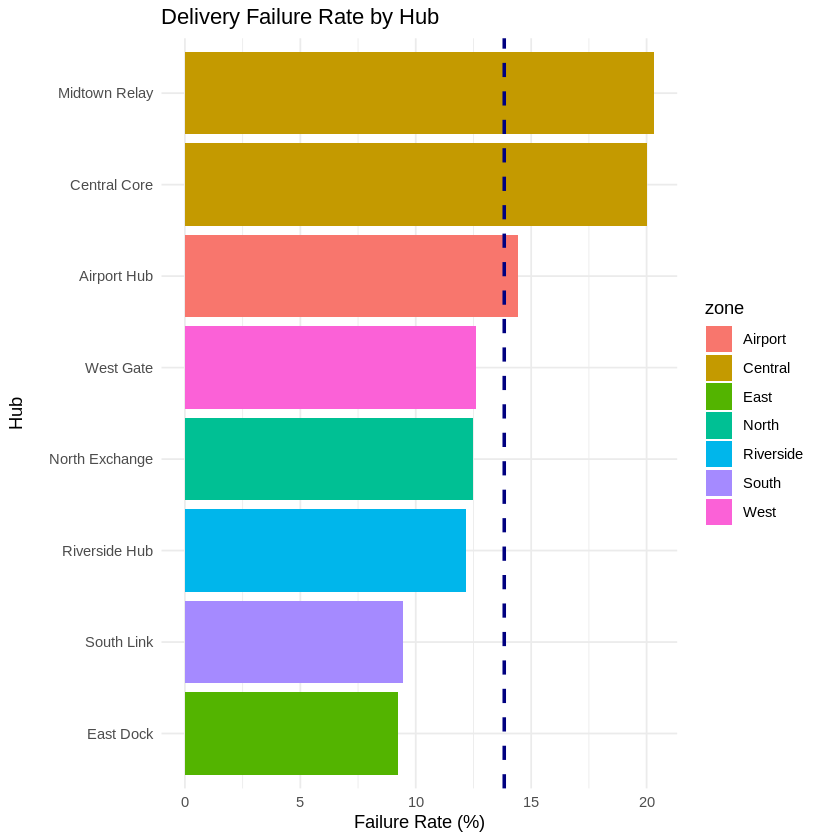

In [6]:
q1 <- dbGetQuery(con, "
SELECT
    h.hub_name,
    h.zone,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(
        SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 /
        COUNT(d.delivery_id), 2
    ) AS failure_rate
FROM deliveries d
JOIN hubs h ON d.hub_id = h.hub_id
GROUP BY h.hub_name, h.zone
ORDER BY failure_rate DESC
")

print("=== Q1: Hub Failure Rates ===")
print(q1)

ggplot(q1, aes(x=reorder(hub_name, failure_rate), y=failure_rate, fill=zone)) +
  geom_bar(stat="identity") +
  coord_flip() +
  geom_hline(yintercept=mean(q1$failure_rate), linetype="dashed",
             color="navy", linewidth=1) +
  theme_minimal() +
  ggtitle("Delivery Failure Rate by Hub") +
  xlab("Hub") +
  ylab("Failure Rate (%)")

In [7]:
q2 <- dbGetQuery(con, "
SELECT
    CASE
        WHEN dr.training_score >= 75 THEN 'High'
        WHEN dr.training_score >= 50 THEN 'Medium'
        ELSE 'Low'
    END AS training_tier,
    COUNT(d.delivery_id) AS total_deliveries,
    ROUND(AVG(dr.driver_rating), 2) AS avg_driver_rating,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_route_overrides,
    ROUND(
        AVG(
            ((julianday(d.delivery_completed_at) - julianday(d.dispatch_time)) * 24)
            - o.promised_window_hours
        ), 2
    ) AS avg_delay_hours
FROM deliveries d
JOIN drivers dr ON d.driver_id = dr.driver_id
JOIN orders o ON d.order_id = o.order_id
GROUP BY training_tier
HAVING total_deliveries > 5
ORDER BY avg_delay_hours DESC
")

print("=== Q2: Training Tier vs Driver KPIs ===")
print(q2)

[1] "=== Q2: Training Tier vs Driver KPIs ==="
  training_tier total_deliveries avg_driver_rating avg_customer_rating
1        Medium              442              4.17                3.86
2           Low               68              4.28                3.78
3          High              440              4.13                3.88
  avg_route_overrides avg_delay_hours
1                1.00              NA
2                0.91              NA
3                0.95              NA


[1] "=== Q3: Zone Complaint Hotspots ==="
       zone total_orders total_complaints complaint_rate
1   CENTRAL          127               38          29.92
2     SOUTH          178               53          29.78
3     NORTH          191               52          27.23
4   AIRPORT          163               44          26.99
5      WEST          197               50          25.38
6      EAST          155               36          23.23
7 RIVERSIDE          181               38          20.99
8       CTR           58                9          15.52


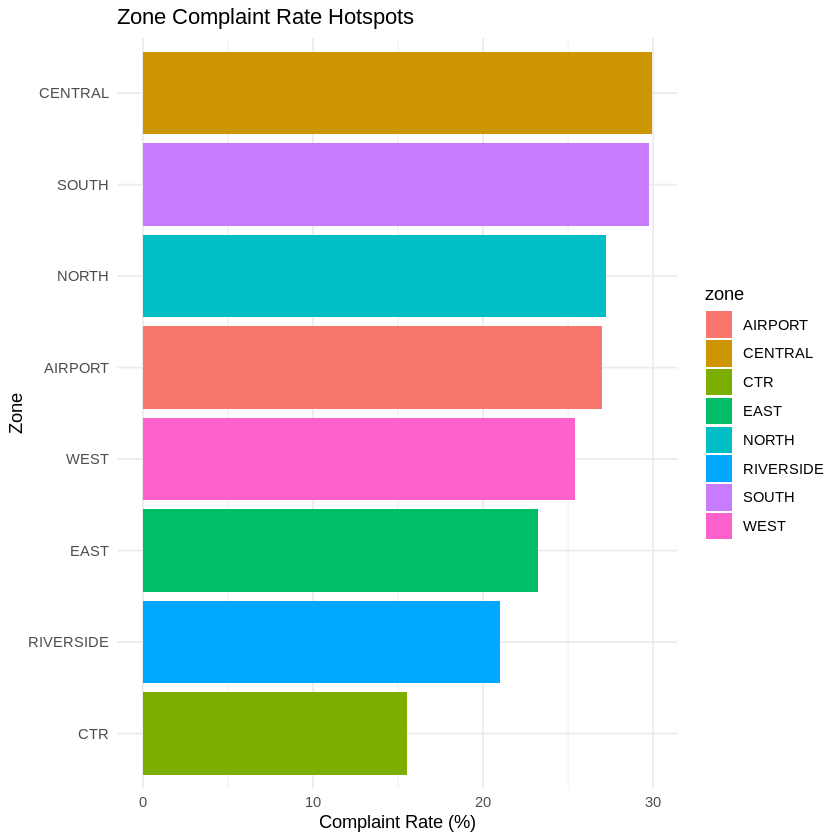

In [8]:
q3 <- dbGetQuery(con, "
SELECT
    UPPER(TRIM(o.dropoff_zone)) AS zone,
    COUNT(DISTINCT o.order_id) AS total_orders,
    COUNT(c.complaint_id) AS total_complaints,
    ROUND(COUNT(c.complaint_id) * 100.0 / COUNT(DISTINCT o.order_id), 2) AS complaint_rate
FROM orders o
LEFT JOIN complaints c ON o.order_id = c.order_id
GROUP BY UPPER(TRIM(o.dropoff_zone))
HAVING total_orders > 10
ORDER BY complaint_rate DESC
")

print("=== Q3: Zone Complaint Hotspots ===")
print(q3)

ggplot(q3, aes(x=reorder(zone, complaint_rate),
               y=complaint_rate, fill=zone)) +
  geom_bar(stat="identity") +
  coord_flip() +
  theme_minimal() +
  ggtitle("Zone Complaint Rate Hotspots") +
  xlab("Zone") +
  ylab("Complaint Rate (%)")

In [9]:
q4 <- dbGetQuery(con, "
SELECT
    CASE
        WHEN v.battery_health_pct >= 80 THEN 'Healthy (80%+)'
        WHEN v.battery_health_pct >= 60 THEN 'Moderate (60-79%)'
        ELSE 'Poor (below 60%)'
    END AS battery_tier,
    COUNT(DISTINCT v.vehicle_id) AS vehicle_count,
    COUNT(i.incident_id) AS incident_count,
    ROUND(AVG(v.odometer_km), 2) AS avg_odometer,
    ROUND(AVG(v.battery_health_pct), 2) AS avg_battery_health
FROM vehicles v
LEFT JOIN deliveries d ON v.vehicle_id = d.vehicle_id
LEFT JOIN incidents i ON d.delivery_id = i.delivery_id
GROUP BY battery_tier
ORDER BY incident_count DESC
")

print("=== Q4: Fleet Health vs Incident Exposure ===")
print(q4)

[1] "=== Q4: Fleet Health vs Incident Exposure ==="
       battery_tier vehicle_count incident_count avg_odometer
1 Moderate (60-79%)            56            121     116653.8
2    Healthy (80%+)            47            115     117938.8
3  Poor (below 60%)            17             44     105415.9
  avg_battery_health
1              71.65
2              88.55
3              54.32


In [10]:
q5 <- dbGetQuery(con, "
SELECT
    c.customer_id,
    c.customer_type,
    c.home_zone,
    c.loyalty_score,
    COUNT(o.order_id) AS total_orders,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_orders,
    COUNT(cp.complaint_id) AS complaints
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
LEFT JOIN deliveries d ON o.order_id = d.order_id
LEFT JOIN complaints cp ON o.order_id = cp.order_id
WHERE c.loyalty_score >= 70
GROUP BY c.customer_id, c.customer_type, c.home_zone, c.loyalty_score
HAVING failed_orders > 0 OR complaints > 0
ORDER BY failed_orders DESC, complaints DESC
LIMIT 15
")

print("=== Q5: High-Loyalty Customers Being Failed ===")
print(q5)

[1] "=== Q5: High-Loyalty Customers Being Failed ==="
   customer_id customer_type home_zone loyalty_score total_orders failed_orders
1        C0282      Consumer RiverSide          71.4            3             1
2        C0023      Consumer     South          73.1            6             1
3        C0032      Consumer      West          85.0            5             1
4        C0056      Consumer     NORTH          71.1            3             1
5        C0578           SME       Ctr          74.1            3             1
6        C0583      Consumer   AIRPORT          84.2            2             1
7        C0123           SME     SOUTH          76.8            2             1
8        C0145      Consumer   AIRPORT          99.0            3             1
9        C0171      Consumer     SOUTH          82.4            2             1
10       C0175      Consumer   CENTRAL          86.4            3             1
11       C0292      Consumer     South          73.2            4 

[1] "=== Q6: Route Override Hotspots ==="
   pickup_zone dropoff_zone total_deliveries total_overrides avg_overrides
1      AIRPORT        SOUTH               13              34          2.62
2      AIRPORT      CENTRAL               11              23          2.09
3      AIRPORT         EAST               11              23          2.09
4      CENTRAL      CENTRAL                7              14          2.00
5      CENTRAL         EAST               15              29          1.93
6      CENTRAL        NORTH               18              32          1.78
7      AIRPORT        NORTH               19              32          1.68
8      AIRPORT    RIVERSIDE               17              28          1.65
9      CENTRAL      AIRPORT               18              29          1.61
10     AIRPORT         WEST               17              26          1.53
   avg_distance
1         28.25
2         28.13
3         26.26
4          9.21
5         12.72
6         12.58
7         28.17
8    

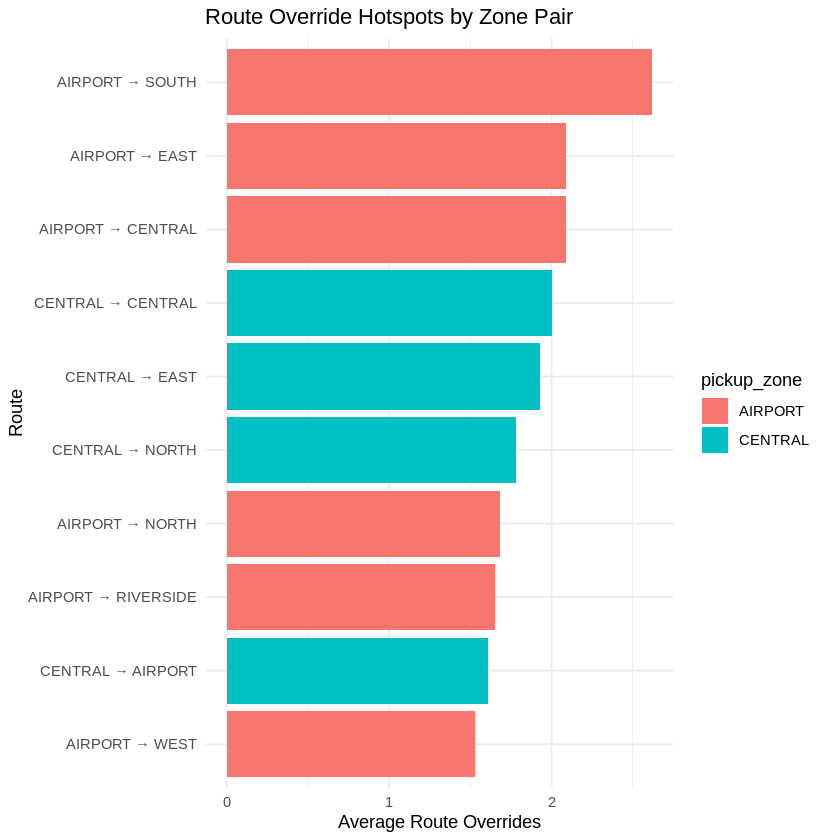

In [11]:
q6 <- dbGetQuery(con, "
SELECT
    UPPER(TRIM(o.pickup_zone)) AS pickup_zone,
    UPPER(TRIM(o.dropoff_zone)) AS dropoff_zone,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(d.manual_route_override_count) AS total_overrides,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides,
    ROUND(AVG(d.route_distance_km), 2) AS avg_distance
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
GROUP BY UPPER(TRIM(o.pickup_zone)), UPPER(TRIM(o.dropoff_zone))
HAVING total_deliveries >= 5
ORDER BY avg_overrides DESC
LIMIT 10
")

print("=== Q6: Route Override Hotspots ===")
print(q6)

ggplot(q6,
       aes(x=reorder(paste(pickup_zone, dropoff_zone, sep=" → "),
                     avg_overrides),
           y=avg_overrides, fill=pickup_zone)) +
  geom_bar(stat="identity") +
  coord_flip() +
  theme_minimal() +
  ggtitle("Route Override Hotspots by Zone Pair") +
  xlab("Route") +
  ylab("Average Route Overrides")

In [12]:
analytics_data <- dbGetQuery(con, "
SELECT
    d.delivery_id,
    d.delivery_status,
    d.route_distance_km,
    d.manual_route_override_count,
    d.customer_rating_post_delivery,
    d.fuel_or_charge_cost,
    d.proof_of_completion_missing,
    ((julianday(d.delivery_completed_at) - julianday(d.dispatch_time)) * 24)
        - o.promised_window_hours AS delay_hours,
    o.service_type,
    o.order_value,
    o.pickup_zone,
    o.dropoff_zone,
    o.order_created_at,
    dr.training_score,
    dr.driver_rating,
    dr.years_experience,
    h.hub_name,
    h.zone,
    h.capacity_score
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
JOIN drivers dr ON d.driver_id = dr.driver_id
JOIN hubs h ON d.hub_id = h.hub_id
WHERE d.delivery_completed_at IS NOT NULL
  AND d.delivery_completed_at > d.dispatch_time
")

analytics_data$training_tier <- ifelse(
  analytics_data$training_score >= 75, "High",
  ifelse(analytics_data$training_score >= 50, "Medium", "Low")
)

analytics_data$order_created_at <- as.POSIXct(
  analytics_data$order_created_at, format="%Y-%m-%d %H:%M:%S", tz="UTC"
)

analytics_data$month <- format(analytics_data$order_created_at, "%Y-%m")

print(paste("✅ Analytics data ready:", nrow(analytics_data), "rows"))
head(analytics_data)

[1] "✅ Analytics data ready: 867 rows"


,delivery_id,delivery_status,route_distance_km,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost,proof_of_completion_missing,delay_hours,service_type,order_value,⋯,dropoff_zone,order_created_at,training_score,driver_rating,years_experience,hub_name,zone,capacity_score,training_tier,month
,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<lgl>,<chr>,<dbl>,⋯,<chr>,<dttm>,<dbl>,<dbl>,<int>,<chr>,<chr>,<int>,<chr>,<chr>
1,DL00001,Failed,17.26,1,3.07,12.05,0,NA,Business,151.14,⋯,CENTRAL,2024-06-18 09:48:00,88.9,4.75,13,Central Core,Central,88,High,2024-06
2,DL00003,OnTime,7.92,0,4.98,8.51,0,NA,Medical,141.93,⋯,NORTH,2025-06-02 19:12:00,78.8,4.38,8,South Link,South,78,High,2025-06
3,DL00004,Delayed,16.42,0,4.18,13.62,0,NA,Medical,11.11,⋯,north,2024-03-08 20:58:00,58.2,4.19,4,South Link,South,78,Medium,2024-03
4,DL00005,OnTime,14.52,1,4.18,9.22,0,NA,Medical,76.02,⋯,RiverSide,2025-09-21 09:29:00,70.6,4.33,10,North Exchange,North,82,Medium,2025-09
5,DL00006,Delayed,13.84,0,1.57,9.58,0,NA,Medical,190.94,⋯,Ctr,2024-09-11 12:22:00,63.9,4.67,7,East Dock,East,74,Medium,2024-09
6,DL00007,Delayed,32.72,0,4.64,17.70,0,NA,Parcel,72.64,⋯,Airport,2024-01-09 11:58:00,71.3,4.69,2,Riverside Hub,Riverside,66,Medium,2024-01


In [13]:
print("=== R1: ANOVA — Driver Rating by Training Tier ===")
anova_result <- aov(driver_rating ~ training_tier, data=analytics_data)
summary(anova_result)

cat("\nInterpretation:\n")
cat("If p-value < 0.05: training tier significantly affects driver rating\n")
cat("If p-value > 0.05: no significant difference between tiers\n")

[1] "=== R1: ANOVA — Driver Rating by Training Tier ==="


               Df Sum Sq Mean Sq F value Pr(>F)  
training_tier   2   0.81  0.4029    2.38 0.0932 .
Residuals     828 140.15  0.1693                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
36 observations deleted due to missingness


Interpretation:
If p-value < 0.05: training tier significantly affects driver rating
If p-value > 0.05: no significant difference between tiers


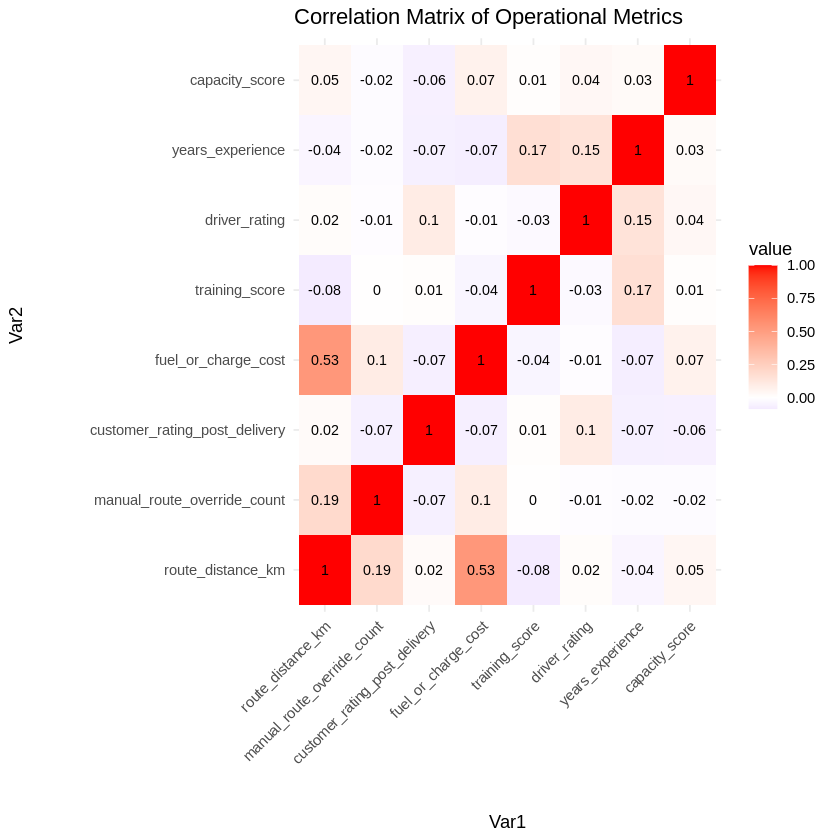

In [14]:
library(reshape2)

corr_vars <- data.frame(
  route_distance_km = analytics_data$route_distance_km,
  manual_route_override_count = analytics_data$manual_route_override_count,
  customer_rating_post_delivery = analytics_data$customer_rating_post_delivery,
  fuel_or_charge_cost = analytics_data$fuel_or_charge_cost,
  delay_hours = analytics_data$delay_hours,
  training_score = analytics_data$training_score,
  driver_rating = analytics_data$driver_rating,
  years_experience = analytics_data$years_experience,
  capacity_score = analytics_data$capacity_score
)

corr_vars <- corr_vars[, colSums(is.na(corr_vars)) < nrow(corr_vars)]
corr_vars <- na.omit(corr_vars)

corr_matrix <- cor(corr_vars)
corr_melted <- melt(corr_matrix)

ggplot(corr_melted, aes(x=Var1, y=Var2, fill=value)) +
  geom_tile() +
  geom_text(aes(label=round(value, 2)), size=3) +
  scale_fill_gradient2(low="blue", high="red", mid="white", midpoint=0) +
  theme_minimal() +
  ggtitle("Correlation Matrix of Operational Metrics") +
  theme(axis.text.x = element_text(angle=45, hjust=1))

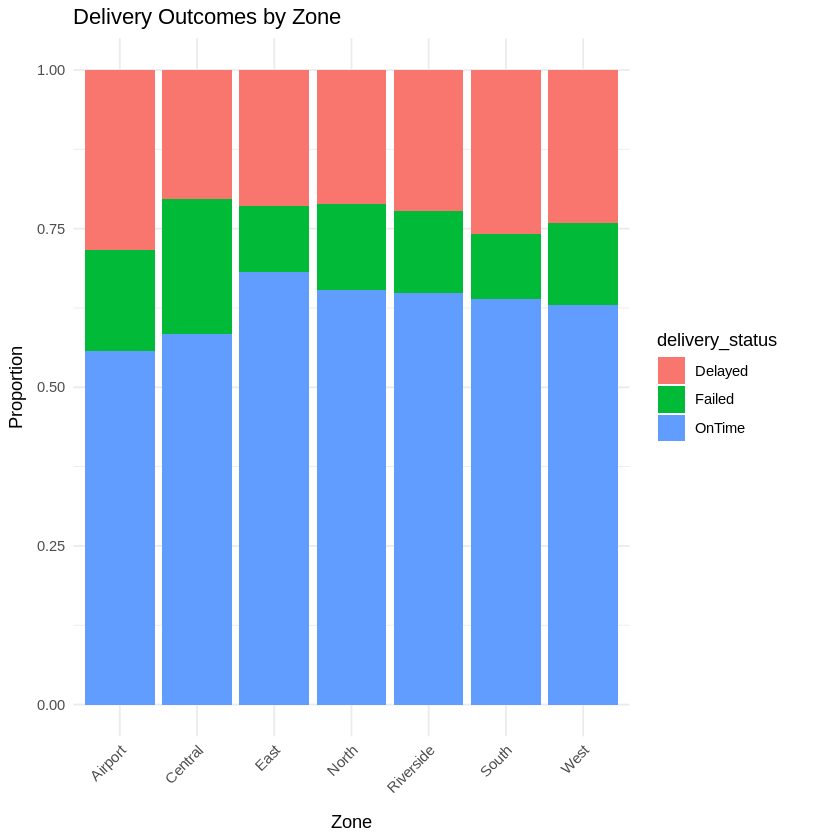

In [15]:
ggplot(analytics_data, aes(x=zone, fill=delivery_status)) +
  geom_bar(position="fill") +
  theme_minimal() +
  ggtitle("Delivery Outcomes by Zone") +
  xlab("Zone") + ylab("Proportion") +
  theme(axis.text.x=element_text(angle=45, hjust=1))

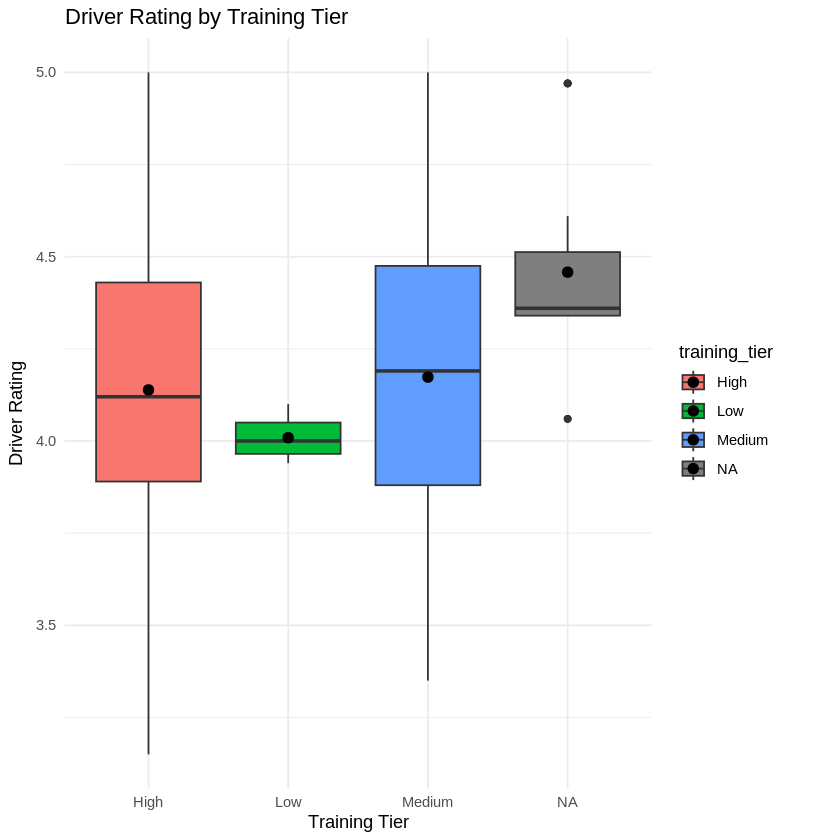

In [16]:
ggplot(analytics_data, aes(x=training_tier, y=driver_rating, fill=training_tier)) +
  geom_boxplot() +
  stat_summary(fun=mean, geom="point", shape=20, size=4, color="black") +
  theme_minimal() +
  ggtitle("Driver Rating by Training Tier") +
  xlab("Training Tier") + ylab("Driver Rating")

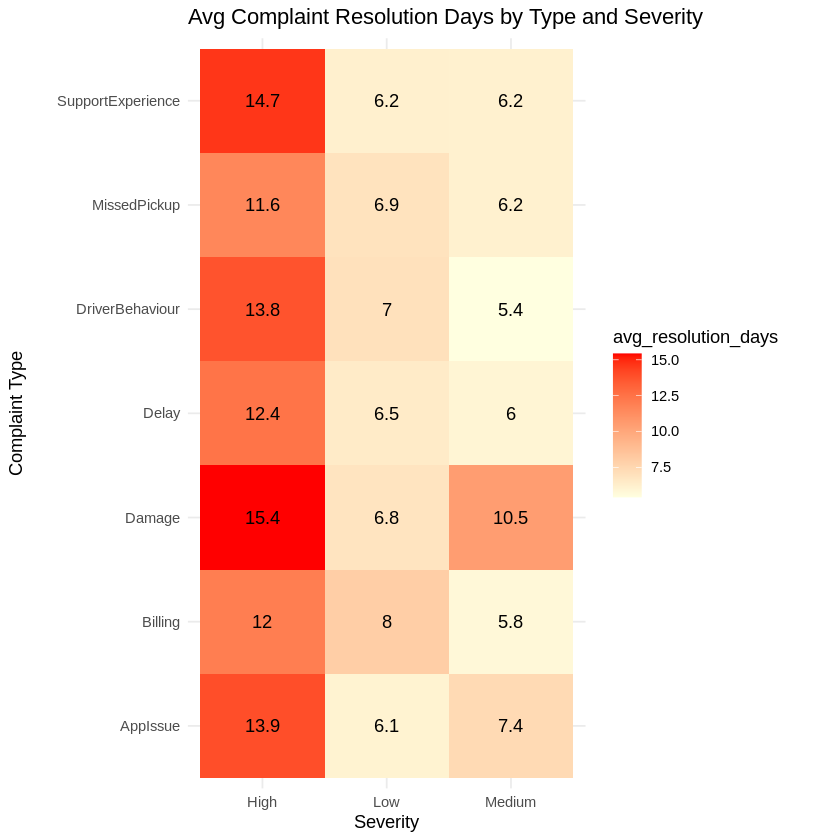

In [17]:
complaint_heatmap <- complaints %>%
  group_by(complaint_type, severity) %>%
  summarise(avg_resolution_days=mean(resolution_days, na.rm=TRUE),
            .groups="drop")
            ggplot(complaint_heatmap,
       aes(x=severity, y=complaint_type, fill=avg_resolution_days)) +
  geom_tile() +
  geom_text(aes(label=round(avg_resolution_days,1)), color="black") +
  scale_fill_gradient(low="lightyellow", high="red") +
  theme_minimal() +
  ggtitle("Avg Complaint Resolution Days by Type and Severity") +
  xlab("Severity") + ylab("Complaint Type")


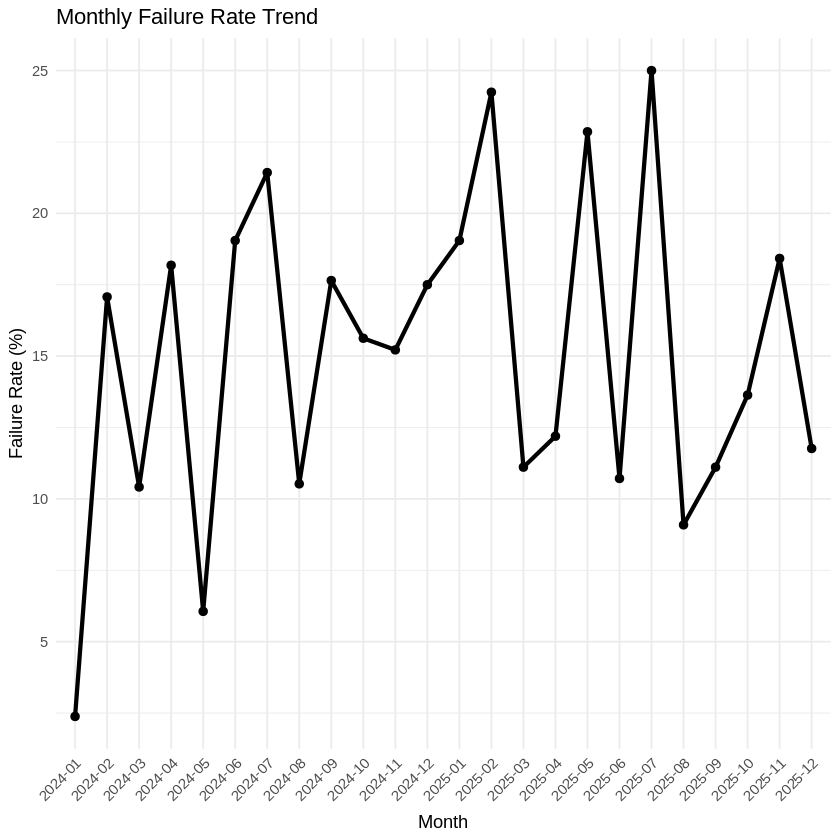

In [18]:
monthly_trend <- analytics_data %>%
  group_by(month) %>%
  summarise(
    total_deliveries = n(),
    failure_rate     = mean(delivery_status == "Failed") * 100,
    avg_delay_hours  = mean(delay_hours, na.rm=TRUE),
    .groups="drop"
  )

ggplot(monthly_trend, aes(x=month, y=failure_rate, group=1)) +
  geom_line(linewidth=1.2) +
  geom_point(size=2) +
  theme_minimal() +
  ggtitle("Monthly Failure Rate Trend") +
  xlab("Month") + ylab("Failure Rate (%)") +
  theme(axis.text.x=element_text(angle=45, hjust=1))

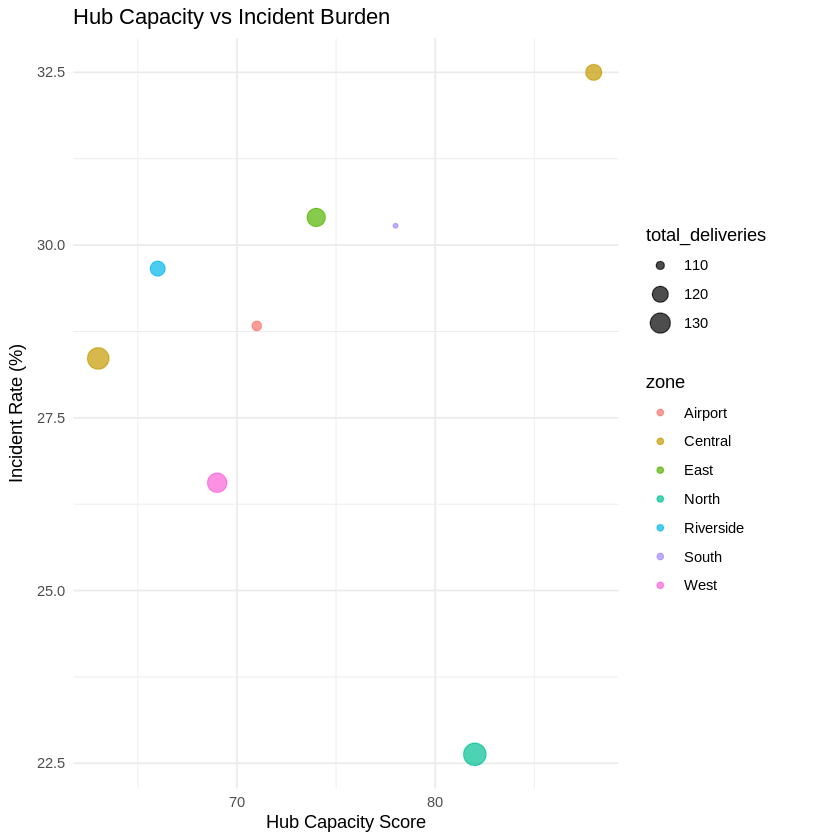

In [19]:
hub_incidents <- dbGetQuery(con, "
SELECT
    h.hub_name, h.zone, h.capacity_score,
    COUNT(d.delivery_id) AS total_deliveries,
    COUNT(i.incident_id) AS incident_count,
    ROUND(COUNT(i.incident_id) * 100.0 / COUNT(d.delivery_id), 2) AS incident_rate
FROM hubs h
LEFT JOIN deliveries d ON h.hub_id = d.hub_id
LEFT JOIN incidents i ON d.delivery_id = i.delivery_id
GROUP BY h.hub_name, h.zone, h.capacity_score
")

ggplot(hub_incidents,
       aes(x=capacity_score, y=incident_rate,
           size=total_deliveries, color=zone)) +
  geom_point(alpha=0.7) +
  theme_minimal() +
  ggtitle("Hub Capacity vs Incident Burden") +
  xlab("Hub Capacity Score") + ylab("Incident Rate (%)")

In [20]:
dbDisconnect(con)
print("✅ Database connection closed. All done!")

[1] "✅ Database connection closed. All done!"
